In [2]:
!pip install pmdarima

In [3]:
!pip install keras-tcn


In [4]:
# ===============================================================
# 🧠 Step 1: Import Libraries
# ===============================================================
print("="*60)
print("🧠 STEP 1 START: Importing libraries...")
print("="*60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tcn import TCN

print("✅ STEP 1 COMPLETE: Libraries imported")



🧠 STEP 1 START: Importing libraries...
✅ STEP 1 COMPLETE: Libraries imported


In [5]:
# ===============================================================
# 🧠 Step 2: Load and Prepare Dataset
# ===============================================================
print("="*60)
print("🧠 STEP 2 START: Loading and preprocessing data...")
print("="*60)

file_path = 'Electric_Vehicle_Charging_Station_Data.csv'
df = pd.read_csv(file_path)

df['Start_Date___Time'] = pd.to_datetime(df['Start_Date___Time'], format='mixed')
df['End_Date___Time']   = pd.to_datetime(df['End_Date___Time'], format='mixed')

df['Charging_Time__hh_mm_ss_'] = pd.to_timedelta(df['Charging_Time__hh_mm_ss_'])
df['Charging_Hours'] = df['Charging_Time__hh_mm_ss_'].dt.total_seconds() / 3600
df['Charging_Hours'] = df['Charging_Hours'].replace(0, np.nan)

df['Energy_per_Hour'] = df['Energy__kWh_'] / df['Charging_Hours']
df = df.dropna(subset=['Start_Date___Time', 'End_Date___Time', 'Energy_per_Hour'])

start_date = df['Start_Date___Time'].min().floor('H')
end_date   = df['End_Date___Time'].max().ceil('H')
hourly_index = pd.date_range(start=start_date, end=end_date, freq='H')

df_hourly_load = pd.DataFrame(index=hourly_index, columns=['Energy_kWh'])
df_hourly_load['Energy_kWh'] = 0.0

print("⏳ Distributing energy across hourly buckets...")

for _, row in tqdm(df.iterrows(), total=len(df), desc="Energy distribution"):
    current_time = row['Start_Date___Time'].floor('H')
    end_time = row['End_Date___Time'].ceil('H')
    energy_rate = row['Energy_per_Hour']

    while current_time <= end_time:
        next_hour = current_time + timedelta(hours=1)

        start_overlap = max(row['Start_Date___Time'], current_time)
        end_overlap   = min(row['End_Date___Time'], next_hour)

        overlap_seconds = (end_overlap - start_overlap).total_seconds()

        if overlap_seconds > 0 and current_time in df_hourly_load.index:
            df_hourly_load.loc[current_time, 'Energy_kWh'] += (
                overlap_seconds / 3600
            ) * energy_rate

        current_time = next_hour

df_hourly = df_hourly_load.copy()

print("✅ STEP 2 COMPLETE: Hourly load created")


🧠 STEP 2 START: Loading and preprocessing data...


C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_17728\247617767.py:21: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  start_date = df['Start_Date___Time'].min().floor('H')
C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_17728\247617767.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_date   = df['End_Date___Time'].max().ceil('H')
C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_17728\247617767.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_index = pd.date_range(start=start_date, end=end_date, freq='H')


⏳ Distributing energy across hourly buckets...


Energy distribution:   0%|                                                                  | 0/133029 [00:00<?, ?it/s]C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_17728\247617767.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  current_time = row['Start_Date___Time'].floor('H')
C:\Users\ASUS TUF-Pc\AppData\Local\Temp\ipykernel_17728\247617767.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end_time = row['End_Date___Time'].ceil('H')
Energy distribution: 100%|████████████████████████████████████████████████████| 133029/133029 [06:02<00:00, 367.34it/s]

✅ STEP 2 COMPLETE: Hourly load created


In [6]:
# ===============================================================
# 🧠 Step 3: Train–Test Split (Time-Based)
# ===============================================================
print("="*60)
print("🧠 STEP 3 START: Creating calendar features & splitting data...")
print("="*60)

df_hourly.index.name = 'Datetime'

df_hourly['hour'] = df_hourly.index.hour
df_hourly['day_of_week'] = df_hourly.index.dayofweek

df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly['hour'] / 24)
df_hourly['day_sin']  = np.sin(2 * np.pi * df_hourly['day_of_week'] / 7)
df_hourly['day_cos']  = np.cos(2 * np.pi * df_hourly['day_of_week'] / 7)

data = df_hourly['Energy_kWh']
features = df_hourly[['hour_sin', 'hour_cos', 'day_sin', 'day_cos']]

split_point = int(len(data) * 0.8)

train = data.iloc[:split_point]
test  = data.iloc[split_point:]

train_features = features.iloc[:split_point]
test_features  = features.iloc[split_point:]

print("✅ STEP 3 COMPLETE")


🧠 STEP 3 START: Creating calendar features & splitting data...
✅ STEP 3 COMPLETE


In [7]:
# ===============================================================
# 🧠 Step 4: Feature Scaling
# ===============================================================
print("="*60)
print("🧠 STEP 4 START: Scaling data...")
print("="*60)

y_scaler = StandardScaler()
x_scaler = StandardScaler()

y_train = y_scaler.fit_transform(train.values.reshape(-1,1))
y_test  = y_scaler.transform(test.values.reshape(-1,1))

X_train_feat = x_scaler.fit_transform(train_features)
X_test_feat  = x_scaler.transform(test_features)

print("✅ STEP 4 COMPLETE")


🧠 STEP 4 START: Scaling data...
✅ STEP 4 COMPLETE


In [8]:
# ===============================================================
# 🧠 Step 5: Create TCN Sequences (NON-RECURSIVE)
# ===============================================================
print("="*60)
print("🧠 STEP 5 START: Creating TCN sequences...")
print("="*60)

WINDOW_SIZE = 24
HORIZON = 1

def create_sequences(y, X, window, horizon):
    X_seq, y_seq = [], []
    for i in tqdm(range(window, len(y) - horizon + 1), desc="Sequence building"):
        X_window = np.hstack([y[i-window:i], X[i-window:i]])
        X_seq.append(X_window)
        y_seq.append(y[i:i+horizon])
    return np.array(X_seq), np.array(y_seq)

X_train, y_train_seq = create_sequences(y_train, X_train_feat, WINDOW_SIZE, HORIZON)
X_test,  y_test_seq  = create_sequences(y_test,  X_test_feat,  WINDOW_SIZE, HORIZON)

print("✅ STEP 5 COMPLETE")


🧠 STEP 5 START: Creating TCN sequences...


Sequence building: 100%|█████████████████████████████████████████████████████| 10361/10361 [00:00<00:00, 123976.35it/s]


✅ STEP 5 COMPLETE


🧬 STEP 6 START: GA-TCN Optimization

🔵 [START] GA MAIN LOOP

🔵 [START] Initializing Population
🟢 [END] Population Initialized

🔁 GENERATION 1 START

🔵 [START] Fitness Evaluation
   → Generation 1
------------------------------------------------------------


Evaluating Individuals:   0%|                                                                    | 0/8 [00:00<?, ?it/s]


   🔹 Individual 1/8
      Params: {'filters': 32, 'kernel_size': 5, 'dropout': 0.16768475627168972, 'learning_rate': 0.001}

      ✅ RMSE: 0.836349


Evaluating Individuals:  12%|███████▏                                                 | 1/8 [11:16<1:18:55, 676.48s/it]


   🔹 Individual 2/8
      Params: {'filters': 64, 'kernel_size': 5, 'dropout': 0.18223930349695255, 'learning_rate': 0.0001}
      ✅ RMSE: 0.720600


...


   🔹 Individual 7/8
      Params: {'filters': 32, 'kernel_size': 3, 'dropout': 0.24415486192903813, 'learning_rate': 0.0005}
      ✅ RMSE: 0.744164


Evaluating Individuals:  88%|████████████████████████████████████████████████████████        | 7/8 [1:38:49<14:14, 854.20s/it]


   🔹 Individual 8/8
      Params: {'filters': 32, 'kernel_size': 3, 'dropout': 0.12631094423046854, 'learning_rate': 0.0005}
      ✅ RMSE: 0.737237


Evaluating Individuals: 100%|████████████████████████████████████████████████████████████████| 8/8 [1:53:44<00:00, 853.11s/it]


🟢 [END] Fitness Evaluation Completed


🏆 Best RMSE: 0.668165
📊 Avg RMSE : 0.725717
🟢 GENERATION 5 END

🟢 [END] GA MAIN LOOP

🎯 FINAL BEST PARAMETERS:
{'filters': 32, 'kernel_size': 3, 'dropout': 0.12631094423046854, 'learning_rate': 0.0005}

🔵 [START] Plotting GA Convergence


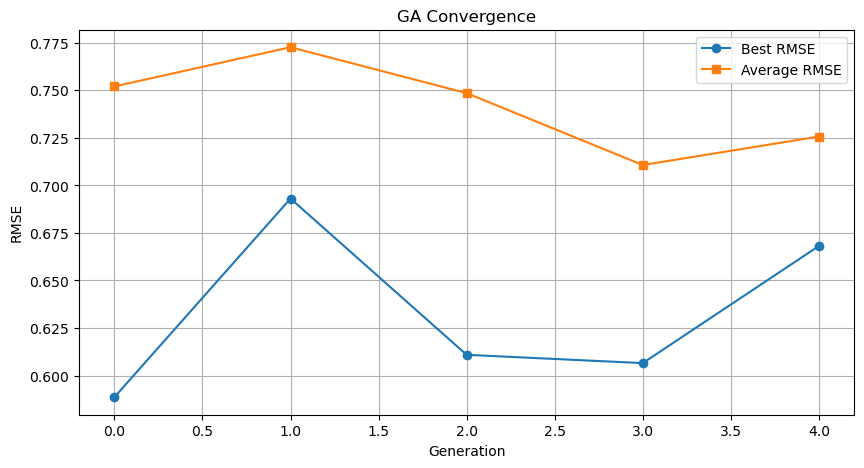

🟢 [END] Plotting Complete
🟢 STEP 6 COMPLETE: GA-TCN Finished Successfully


In [9]:

#===============================================================
#🧬 STEP 6: GA-TCN WITH CLEAR START / END MARKERS
#===============================================================

print("="*70)
print("🧬 STEP 6 START: GA-TCN Optimization")
print("="*70)

import random
import json
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error


# ===============================================================
# 🔹 PART 1: INITIALIZE POPULATION
# ===============================================================
def initialize_population(pop_size):

    print("\n🔵 [START] Initializing Population")

    population = [
        {
            "filters": random.choice([32, 64, 128]),
            "kernel_size": random.choice([2, 3, 5]),
            "dropout": random.uniform(0.1, 0.3),
            "learning_rate": random.choice([0.001, 0.0005, 0.0001])
        }
        for _ in range(pop_size)
    ]

    print("🟢 [END] Population Initialized")
    return population


# ===============================================================
# 🔹 PART 2: BUILD MODEL
# ===============================================================
def build_tcn_model(params):

    model = Sequential([
        tf.keras.Input(shape=(X_train.shape[1], X_train.shape[2])),

        TCN(
            nb_filters=params["filters"],
            kernel_size=params["kernel_size"],
            dilations=[1,2,4,8,16],
            dropout_rate=params["dropout"],
            return_sequences=False
        ),

        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss='mse'
    )

    return model


# ===============================================================
# 🔹 PART 3: FITNESS EVALUATION
# ===============================================================
def fitness_function(population, generation):

    print("\n🔵 [START] Fitness Evaluation")
    print(f"   → Generation {generation}")
    print("-"*60)

    results = []

    for idx, individual in enumerate(tqdm(population, desc="Evaluating Individuals")):

        print(f"\n   🔹 Individual {idx+1}/{len(population)}")
        print(f"      Params: {individual}")

        try:
            model = build_tcn_model(individual)

            model.fit(
                X_train,
                y_train_seq,
                validation_split=0.2,
                epochs=30,
                batch_size=32,
                verbose=0
            )

            preds = model.predict(X_test, verbose=0)

            rmse = np.sqrt(
                mean_squared_error(
                    y_test_seq.reshape(-1),
                    preds.reshape(-1)
                )
            )

            print(f"      ✅ RMSE: {rmse:.6f}")

            results.append((rmse, individual))

            tf.keras.backend.clear_session()

        except Exception as e:
            print("      ❌ FAILED:", e)
            tf.keras.backend.clear_session()

    print("🟢 [END] Fitness Evaluation Completed\n")
    return sorted(results, key=lambda x: x[0])


# ===============================================================
# 🔹 PART 4: CROSSOVER
# ===============================================================
def crossover(parent1, parent2):
    return {k: random.choice([parent1[k], parent2[k]]) for k in parent1}


# ===============================================================
# 🔹 PART 5: MUTATION
# ===============================================================
def mutate(individual, mutation_rate=0.3):

    if random.random() < mutation_rate:
        individual["filters"] = random.choice([32,64,128])
    if random.random() < mutation_rate:
        individual["kernel_size"] = random.choice([2,3,5])
    if random.random() < mutation_rate:
        individual["dropout"] = random.uniform(0.1,0.3)
    if random.random() < mutation_rate:
        individual["learning_rate"] = random.choice([0.001,0.0005,0.0001])

    return individual


# ===============================================================
# 🔹 PART 6: MAIN GA LOOP
# ===============================================================
def ga_tcn(generations=5, population_size=8):

    print("\n🔵 [START] GA MAIN LOOP")

    population = initialize_population(population_size)

    best_rmse_history = []
    avg_rmse_history = []

    for generation in range(1, generations+1):

        print("\n" + "="*60)
        print(f"🔁 GENERATION {generation} START")
        print("="*60)

        fitness_results = fitness_function(population, generation)

        if len(fitness_results) == 0:
            print("❌ All individuals failed.")
            break

        rmse_values = [f[0] for f in fitness_results]

        best_rmse = rmse_values[0]
        avg_rmse = np.mean(rmse_values)

        print(f"\n🏆 Best RMSE: {best_rmse:.6f}")
        print(f"📊 Avg RMSE : {avg_rmse:.6f}")

        best_rmse_history.append(best_rmse)
        avg_rmse_history.append(avg_rmse)

        selected = [ind[1] for ind in fitness_results[:population_size//2]]

        children = []
        while len(children) < population_size//2:
            p1, p2 = random.sample(selected, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            children.append(child)

        population = selected + children

        print(f"🟢 GENERATION {generation} END")

    print("\n🟢 [END] GA MAIN LOOP")

    best_params = fitness_results[0][1]

    print("\n🎯 FINAL BEST PARAMETERS:")
    print(best_params)

    # Convergence Plot
    print("\n🔵 [START] Plotting GA Convergence")
    plt.figure(figsize=(10,5))
    plt.plot(best_rmse_history, marker='o', label="Best RMSE")
    plt.plot(avg_rmse_history, marker='s', label="Average RMSE")
    plt.title("GA Convergence")
    plt.xlabel("Generation")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()
    print("🟢 [END] Plotting Complete")

    return best_params


# ===============================================================
# 🔹 RUN GA
# ===============================================================
best_params = ga_tcn(generations=5, population_size=8)

print("="*70)
print("🟢 STEP 6 COMPLETE: GA-TCN Finished Successfully")
print("="*70)



In [10]:
#===============================================================
#🧠 STEP 7: Train Final Optimized TCN
#===============================================================

print("="*60)
print("🧠 STEP 7 START: Training Optimized TCN...")
print("="*60)

best_model = build_tcn_model(best_params)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True
)

history = best_model.fit(
    X_train,
    y_train_seq,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("✅ STEP 7 COMPLETE")


🧠 STEP 7 START: Training Optimized TCN...
Epoch 1/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - loss: 0.6921 - val_loss: 0.6425
Epoch 2/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 31s 29ms/step - loss: 0.2517 - val_loss: 0.6291
Epoch 3/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - loss: 0.2028 - val_loss: 0.6091
Epoch 4/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 39s 37ms/step - loss: 0.1768 - val_loss: 0.4567
Epoch 5/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 29s 28ms/step - loss: 0.1607 - val_loss: 0.3679
Epoch 6/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1567 - val_loss: 0.3509
Epoch 7/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1496 - val_loss: 0.4201
Epoch 8/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.1444 - val_loss: 0.4135
Epoch 9/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1403 - val_loss: 0.4011
Epoch 10/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - loss: 0.1389 - val_loss: 0.3399
Epoch 11/300
1038/1038 ━━━━━━━━━━━━━━━━━━━━ 27s

In [11]:
# ===============================================================
# 🧠 Step 8: Make Predictions (UPDATED FOR GA-TCN)
# ===============================================================
print("="*60)
print("🧠 STEP 8 START: Generating predictions (Optimized TCN)...")
print("="*60)

# --- Predict using optimized model ---
y_pred_scaled = best_model.predict(X_test)

# --- Inverse scaling ---
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_test_seq.reshape(-1, 1))

print("✅ STEP 8 COMPLETE")



🧠 STEP 8 START: Generating predictions (Optimized TCN)...
324/324 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step
✅ STEP 8 COMPLETE


In [12]:
# ===============================================================
# 🧠 Step 9: Model Evaluation
# ===============================================================
print("="*60)
print("🧠 STEP 9 START: Evaluating model...")
print("="*60)

from sklearn.metrics import r2_score

# --- Core error metrics ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# --- SMAPE implementation ---
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred) / np.maximum(denominator, 1e-8)
    return np.mean(diff) * 100

smape_value = smape(y_true, y_pred)

# --- Print results ---
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"R²    : {r2:.4f}")
print(f"SMAPE : {smape_value:.2f}%")

print("✅ STEP 9 COMPLETE")



🧠 STEP 9 START: Evaluating model...
MAE   : 10.8596
RMSE  : 15.7112
R²    : 0.8554
SMAPE : 15.57%
✅ STEP 9 COMPLETE


🧠 STEP 10 START: Plotting results (Full & Zoomed)...


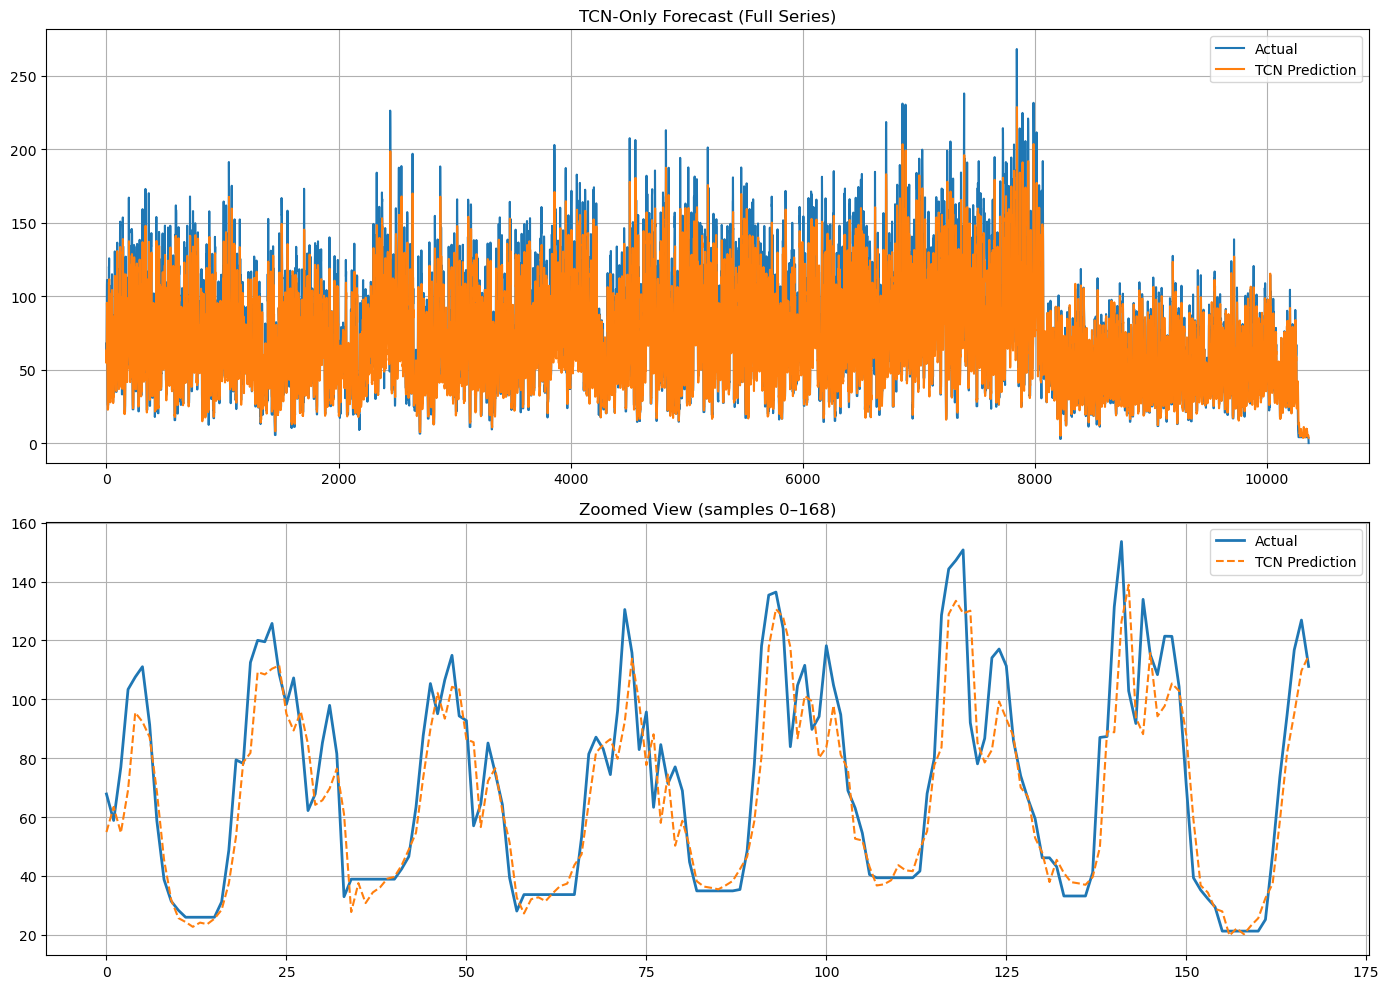

✅ STEP 10 COMPLETE (Full & Zoomed)


In [13]:
# ===============================================================
# 🧠 Step 10: Plot Predictions vs Actual (Full + Zoomed)
# ===============================================================
print("="*60)
print("🧠 STEP 10 START: Plotting results (Full & Zoomed)...")
print("="*60)

zoom_start = 0
zoom_end = 168

plt.figure(figsize=(14,10))

# ---- FULL SERIES ----
plt.subplot(2, 1, 1)
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='TCN Prediction')
plt.title('TCN-Only Forecast (Full Series)')
plt.legend()
plt.grid(True)

# ---- ZOOMED SERIES ----
plt.subplot(2, 1, 2)
plt.plot(y_true[zoom_start:zoom_end], label='Actual', linewidth=2)
plt.plot(y_pred[zoom_start:zoom_end], label='TCN Prediction', linestyle='--')
plt.title(f'Zoomed View (samples {zoom_start}–{zoom_end})')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("✅ STEP 10 COMPLETE (Full & Zoomed)")


In [14]:
# ===============================================================
# 🧠 Step 11: Save Model (For Thesis Reproducibility)
# ===============================================================
#FIX 1 (RECOMMENDED): Use the native Keras format
print("="*60)
print("🧠 STEP 11 START: Saving optimized model (Keras format)...")
print("="*60)

best_model.save("TCN_GA_optimized_model.keras")

print("✅ STEP 11 COMPLETE — Optimized model saved")
print("="*60)



🧠 STEP 11 START: Saving optimized model (Keras format)...
✅ STEP 11 COMPLETE — Optimized model saved


In [15]:
#FIX 2 (ALSO VALID): Save weights only (most robust)

print("="*60)
print("🧠 STEP 11 START: Saving optimized model weights...")
print("="*60)

best_model.save_weights("TCN_GA_optimized_weights.weights.h5")

print("✅ STEP 11 COMPLETE — Optimized weights saved")
print("="*60)



🧠 STEP 11 START: Saving optimized model weights...
✅ STEP 11 COMPLETE — Optimized weights saved


🧠 STEP START: Plotting TCN Forecast...


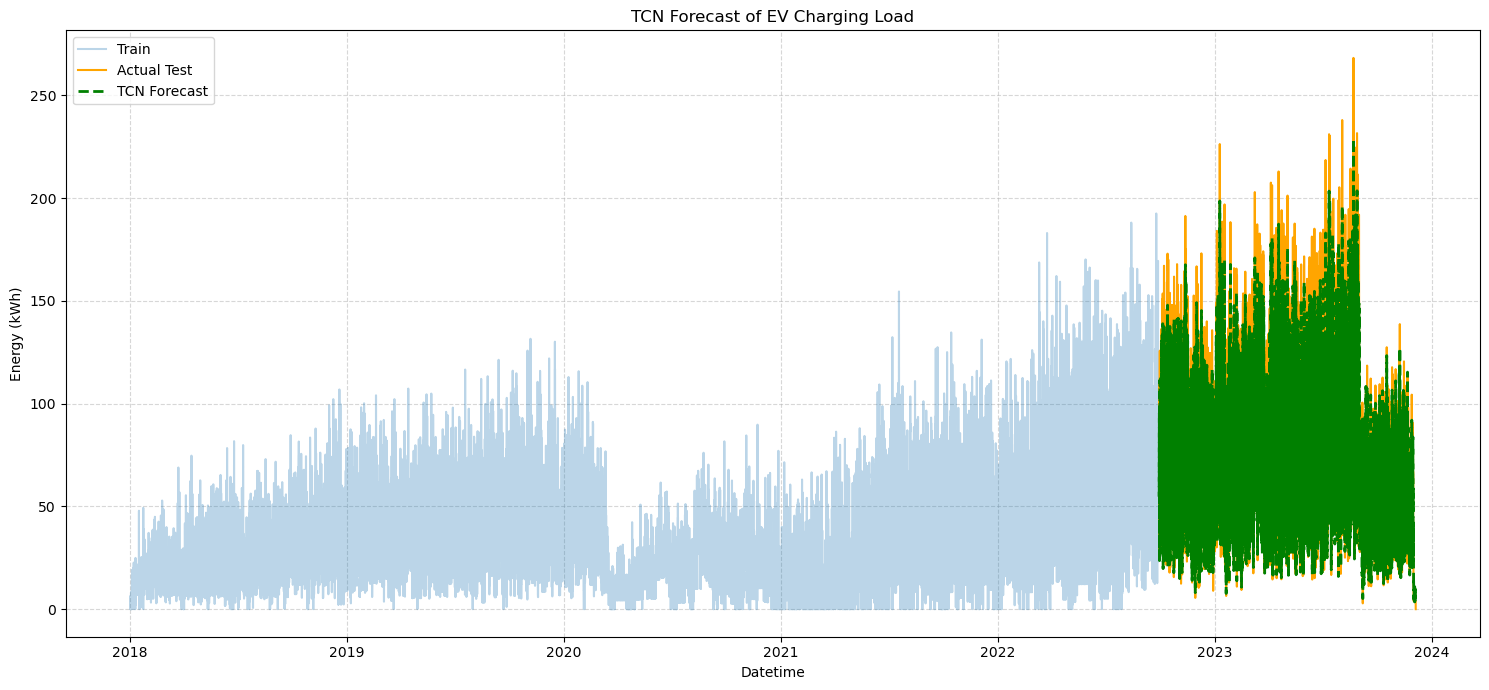

✅ STEP COMPLETE: TCN Forecast Plot Generated


In [16]:
# ===============================================================
# 🧠 Step X: Plot TCN Forecast (Train + Actual + Prediction)
# ===============================================================
import matplotlib.pyplot as plt
import pandas as pd

print("="*60)
print("🧠 STEP START: Plotting TCN Forecast...")
print("="*60)

window_size = X_test.shape[1]  # automatic & safe

# Align TCN predictions with correct timestamps
tcn_forecast = pd.Series(
    y_pred.flatten(),
    index=test.index[window_size:]
)

# Trim actual test data to match predictions
test_aligned = test.iloc[window_size:]

plt.figure(figsize=(15, 7))

# ---- TRAIN DATA ----
plt.plot(train.index, train, label='Train', alpha=0.3)

# ---- ACTUAL TEST DATA (ALIGNED) ----
plt.plot(test_aligned.index, test_aligned, label='Actual Test', color='orange')

# ---- TCN FORECAST ----
plt.plot(
    tcn_forecast.index,
    tcn_forecast,
    label='TCN Forecast',
    color='green',
    linestyle='--',
    linewidth=2
)

plt.title('TCN Forecast of EV Charging Load')
plt.xlabel('Datetime')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ STEP COMPLETE: TCN Forecast Plot Generated")


🧠 STEP START: Plotting Zoomed-In TCN Forecast (First 7 Days)


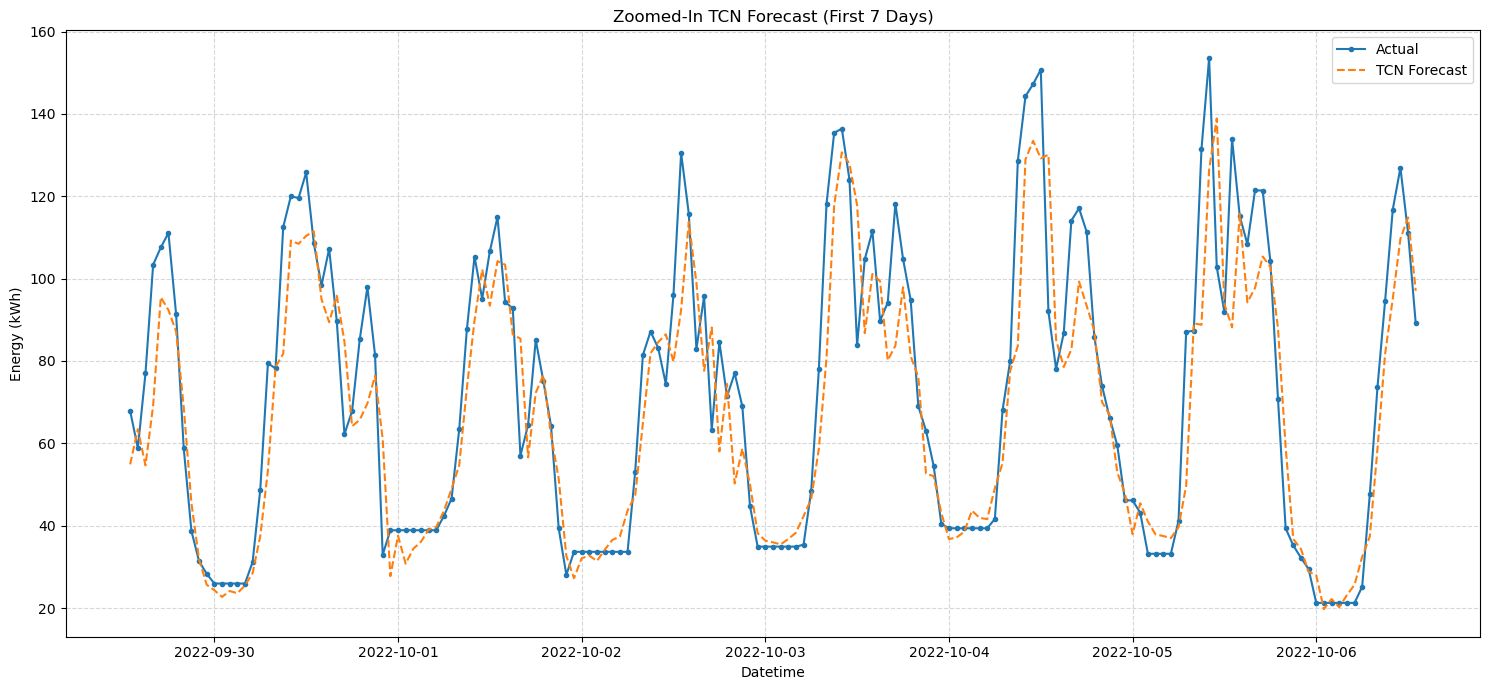

✅ STEP COMPLETE: Zoomed-In TCN Forecast Generated


In [17]:
# ===============================================================
# 🧠 Step X: Zoomed-In TCN Forecast (First 7 Days)
# ===============================================================
import matplotlib.pyplot as plt
from datetime import timedelta
import pandas as pd

print("="*60)
print("🧠 STEP START: Plotting Zoomed-In TCN Forecast (First 7 Days)")
print("="*60)

# Automatically detect window size
window_size = X_test.shape[1]

# Align actual and prediction series
test_aligned = test.iloc[window_size:]
tcn_forecast = pd.Series(
    y_pred.flatten(),
    index=test_aligned.index
)

# Zoom parameters
zoom_days = 7
zoom_start = test_aligned.index[0]
zoom_end = zoom_start + timedelta(days=zoom_days)

plt.figure(figsize=(15, 7))

# ---- ACTUAL DATA ----
plt.plot(
    test_aligned.loc[:zoom_end].index,
    test_aligned.loc[:zoom_end],
    label='Actual',
    marker='.'
)

# ---- TCN FORECAST ----
plt.plot(
    tcn_forecast.loc[:zoom_end].index,
    tcn_forecast.loc[:zoom_end],
    label='TCN Forecast',
    linestyle='--'
)

plt.title(f'Zoomed-In TCN Forecast (First {zoom_days} Days)')
plt.xlabel('Datetime')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("✅ STEP COMPLETE: Zoomed-In TCN Forecast Generated")
